<a href="https://colab.research.google.com/github/si-mong/ComputerVision/blob/main/CV_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HW#2: Digital Image Processing
**2023078086 최은재 제출**

In [1]:
import cv2
import numpy as np

import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow    # colab에서 cv.imshow 사용

In [21]:
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0309(a)(washed_out_aerial_image).tif" #1번 이미지
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0310(b)(washed_out_pollen_image).tif" #2번 이미지
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/school.jpg" # 4번 이미지
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/finger.jpg" # 5번 이미지
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0905(a)(wirebond-mask).tif" # 6번 이미지
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0939(a)(headCT-Vandy).tif" # 7번 이미지
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0938(a)(cygnusloop_Xray_original).tif" # 8번 이미지
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0940(a)(rice_image_with_intensity_gradient).tif" #9번 이미지
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0943(a)(dark_blobs_on_light_background).tif" #10번 이미지



--2026-04-10 13:57:32--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0309(a)(washed_out_aerial_image).tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 589115 (575K) [image/tiff]
Saving to: ‘Fig0309(a)(washed_out_aerial_image).tif.4’

Fig0309(a)(washed_o 100%[===================>] 575.31K  --.-KB/s    in 0.007s  

2026-04-10 13:57:32 (81.1 MB/s) - ‘Fig0309(a)(washed_out_aerial_image).tif.4’ saved [589115/589115]

--2026-04-10 13:57:32--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0310(b)(washed_out_pollen_image).tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443...

## HW#2-1
### 과제 내용
- Fig3.9(a) 영상에 대해 오른쪽과 같은 결과가 나오도록 여러가지 경우에 대해 실험하고, 결과를 분석해보세요.
### 분석 내용
- 감마 보정: s = c · r^γ (c=1). 픽셀값을 0 ~ 1로 정규화한 뒤, γ 제곱하고 다시 0 ~ 255로 변환한다.
- (b) γ=3.0: 흐릿했던 영상의 콘트라스트가 강조되어 도로와 건물 등 구조물이 구분되기 시작한다.
- (c) γ=4.0: 콘트라스트가 더 강해져 세부 구조가 선명해지고, 활주로와 주변 지형이 뚜렷하게 드러난다.
- (d) γ=5.0: 가장 강하게 보정된 결과로 어두운 부분의 디테일이 가장 잘 드러나지만, 원래 밝았던 부분이 너무 어두워지는 경우도 있다

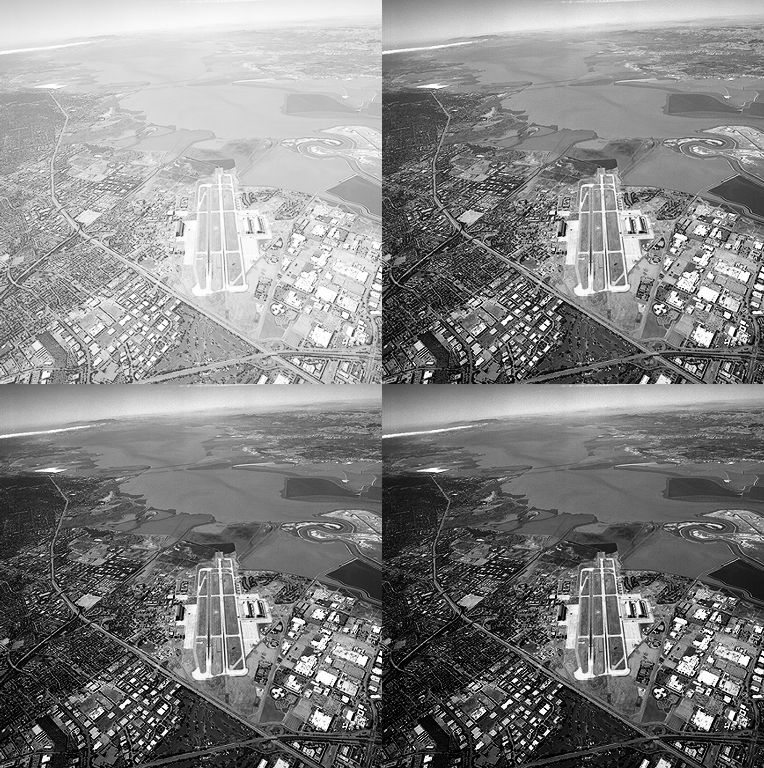

In [45]:
# 과제 1번
img1 = cv2.imread('/content/Fig0309(a)(washed_out_aerial_image).tif', cv2.IMREAD_GRAYSCALE)
img1 = cv2.resize(img1, dsize=(0,0), fx=0.5, fy=0.5)

# 감마 보정
def gamma(f, gamma=1.0):
    f1 = f / 255.0    # 0~255 → 0~1로 정규화
    return np.uint8(255 * (f1 ** gamma))    # 감마 보정 후 다시 0~255로 변환

# (a) 원본, (b) γ=3.0, (c) γ=4.0, (d) γ=5.0
top = np.hstack((img1, gamma(img1, 3.0)))
bottom = np.hstack((gamma(img1, 4.0), gamma(img1, 5.0)))
result = np.vstack((top, bottom))
cv2_imshow(result)

## HW#2-2
### 과제 내용
- Fig3.10(a) 영상에 대해 오른쪽과 같은 결과가 나오도록 여러가지 경우에 대해 실험하고, 결과를 분석해보세요.

### 분석 내용
- 원본: 밝고 대비가 낮은 흐릿한 영상이다.
- Contrast Stretching (히스토그램 평활화):
- equalizeHist로 좁은 범위에 몰려 있던 픽셀값을 0~255 전체로 골고루 펼쳐서 밝은 부분과 어두운 부분의 차이가 커지고, 형태가 뚜렷해진다.
- Thresholding (Otsu 이진화): Otsu 알고리즘이 자동으로 최적의 임계값을 찾아 흑백으로 변환한다. 원두의 윤곽이 확실하게 드러나지만 내부의 밝은 부분의 정보는 손실될 수 잇다.

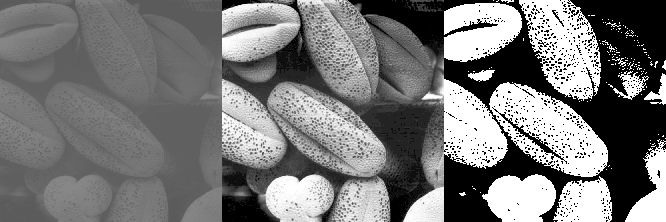

In [46]:
img2 = cv2.imread('/content/Fig0310(b)(washed_out_pollen_image).tif')
img2 = cv2.resize(img2, dsize=(0,0), fx=0.25, fy=0.25)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Contrast Stretching (히스토그램 평활화)
stretched_img = cv2.equalizeHist(img2_gray)

# Thresholding (Otsu 이진화)
t, bin_img = cv2.threshold(stretched_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

show2 = np.hstack((img2_gray, stretched_img, bin_img))
cv2_imshow(show2)

## HW#2-3
### 과제 내용
- 임의의 영상을 입력 받아 아래와 같은 마스크를 사용하여 컨볼루션 하고, 그 결과를 분석해보세요.

### 분석 내용
- **마스크1 (3×3 박스 필터)**: 주변 9개 픽셀의 평균을 구하는 스무딩 필터이다. 영상이 전체적으로 부드러워지고 노이즈가 줄어든다.
-** 마스크2 (5×5 가우시안 필터)**: 중심에 가까울수록 높은 가중치를 주는 스무딩 필터이다. 박스 필터보다 자연스럽게 부드러워지고, 커널이 더 크기 때문에 블러 효과가 더 강하다.
- **마스크3 (라플라시안4)**: 상하좌우 4방향의 에지를 검출하는 샤프닝 마스크이다. 늑대 털의 경계선이 강조되어 나타난다.
- **마스크4 (라플라시안8)**: 대각선 방향까지 포함한 8방향 에지 검출이다. 4방향보다 더 많은 에지가 검출되어 더 세밀한 경계선이 나타난다.
- **마스크 5**: 좌상단→우하단 대각 방향의 변화를 검출한다. 해당 방향의 에지만 강조된다.
- **마스크 6**: 더 넓은 대각 방향의 에지를 검출한다. 마스크 5보다 더 많은 방향의 에지가 포함되어 검출 결과가 더 뚜렷하다.

In [70]:
# 3번 과제
# 3번 이미지 - 제 깃허브 레파지토리에 업로드 한 뒤, 사용하였습니다.
!wget -q "https://raw.githubusercontent.com/si-mong/ComputerVision/main/source/giraffe.jpg"

img3 = cv2.imread('/content/giraffe.jpg')
img3 = cv2.resize(img3, dsize=(0,0), fx=0.25, fy=0.25)
gray3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

In [71]:
# 마스크 1: 3x3 박스 필터 (평균)
kernel1 = np.ones((3,3), np.float32) / 9

# 마스크 2: 5x5 가우시안
kernel2 = np.array([
    [0.0030, 0.0133, 0.0219, 0.0133, 0.0030],
    [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
    [0.0219, 0.0983, 0.1621, 0.0983, 0.0219],
    [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
    [0.0030, 0.0133, 0.0219, 0.0133, 0.0030]], np.float32)

# 마스크 3: 라플라시안 (4)
kernel3 = np.array([
    [ 0, -1,  0],
    [-1,  4, -1],
    [ 0, -1,  0]], np.float32)

# 마스크 4: 라플라시안 (8)
kernel4 = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]], np.float32)

# 마스크 5: 수직 에지
kernel5 = np.array([
    [-1,  0,  0],
    [ 0,  0,  0],
    [ 0,  0,  1]], np.float32)

# 마스크 6: 대각 에지
kernel6 = np.array([
    [-1, -1,  0],
    [-1,  0,  1],
    [ 0,  1,  1]], np.float32)

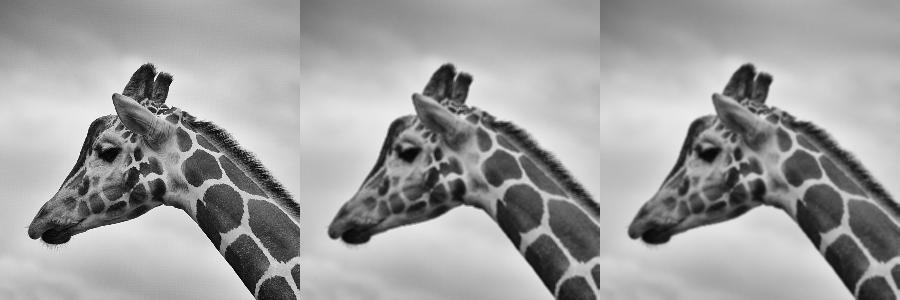

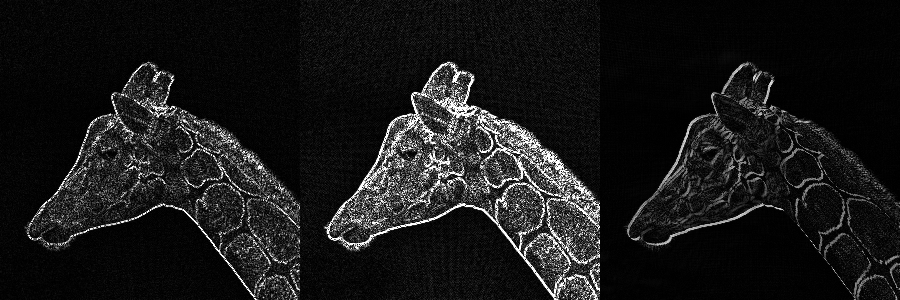

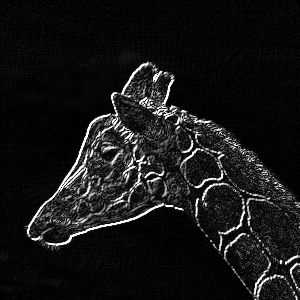

In [72]:
# 컨볼루션 적용
r1 = cv2.filter2D(gray3, -1, kernel1)
r2 = cv2.filter2D(gray3, -1, kernel2)
r3 = cv2.filter2D(gray3, cv2.CV_64F, kernel3)
r3 = np.uint8(np.clip(np.abs(r3), 0, 255))
r4 = cv2.filter2D(gray3, cv2.CV_64F, kernel4)
r4 = np.uint8(np.clip(np.abs(r4), 0, 255))
r5 = cv2.filter2D(gray3, cv2.CV_64F, kernel5)
r5 = np.uint8(np.clip(np.abs(r5), 0, 255))
r6 = cv2.filter2D(gray3, cv2.CV_64F, kernel6)
r6 = np.uint8(np.clip(np.abs(r6), 0, 255))

# 결과 출력
top = np.hstack((gray3, r1, r2))
bottom = np.hstack((r3, r4, r5))
cv2_imshow(top)
cv2_imshow(bottom)
cv2_imshow(r6)

## HW#2-4
### 과제 내용
- 아래와 같은 영상에 대하여 45°,-45° 방향의 대각선 edge를 검출하되, Sobel 연산자를 변형하여 적절한 마스크를 만들어 적용해보세요.
### 분석 내용
- 기존 Sobel 연산자는 수평(Gx)과 수직(Gy) 방향의 에지를 검출한다. 이를 45° 회전시켜 대각선 방향 마스크를 만들었다.
- **45° 마스크** [[0,-1,-2],[1,0,-1],[2,1,0]]: 좌하 → 우상 방향의 에지를 검출한다. 영상에서 해당 방향으로 밝기가 변하는 경계선이 강조된다.
- **-45° 마스크** [[-2,-1,0],[-1,0,1],[0,1,2]]: 좌상 → 우하 방향의 에지를 검출한다. 45° 마스크와 반대 방향의 대각선 경계선이 강조된다.
- 기본 Sobel X는 수직 에지, Sobel Y는 수평 에지만 잘 잡는 반면, 대각선 마스크는 각각 해당 방향의 에지만 선택적으로 검출한다.

In [50]:
# 과제 4번
img4 = cv2.imread('/content/school.jpg')
img4 = cv2.resize(img4, dsize=(0,0), fx=0.5, fy=0.5)
gray4 = cv2.cvtColor(img4, cv2.COLOR_BGR2GRAY)

In [51]:
# 기본 Sobel (수평, 수직)
sobel_x = cv2.convertScaleAbs(cv2.Sobel(gray4, cv2.CV_32F, 1, 0, ksize=3))
sobel_y = cv2.convertScaleAbs(cv2.Sobel(gray4, cv2.CV_32F, 0, 1, ksize=3))

# 45° 방향 대각선 Sobel 마스크 (좌하→우상 방향 에지 검출)
kernel_45 = np.array([
    [ 0, -1, -2],
    [ 1,  0, -1],
    [ 2,  1,  0]], np.float32)

# -45° 방향 대각선 Sobel 마스크 (좌상→우하 방향 에지 검출)
kernel_m45 = np.array([
    [-2, -1,  0],
    [-1,  0,  1],
    [ 0,  1,  2]], np.float32)

# 대각선 에지 검출
sobel_45 = cv2.convertScaleAbs(cv2.filter2D(gray4, cv2.CV_32F, kernel_45))
sobel_m45 = cv2.convertScaleAbs(cv2.filter2D(gray4, cv2.CV_32F, kernel_m45))

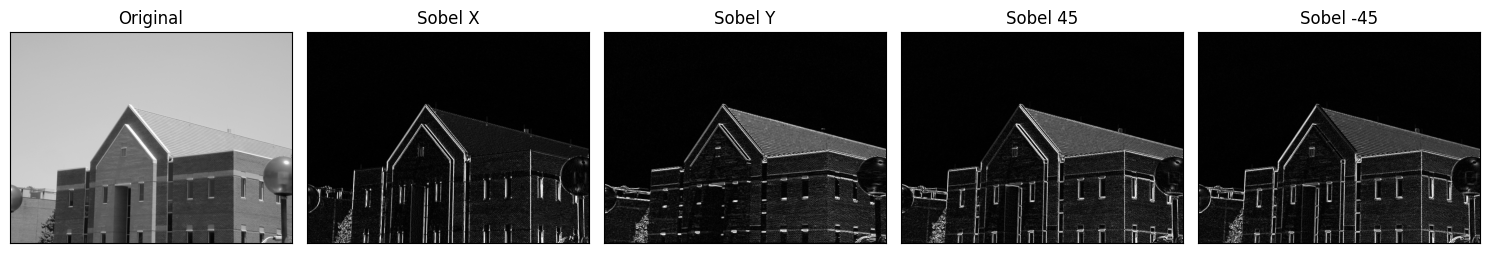

In [52]:
# 결과 출력
titles = ['Original', 'Sobel X', 'Sobel Y', 'Sobel 45', 'Sobel -45']
images = [gray4, sobel_x, sobel_y, sobel_45, sobel_m45]

plt.figure(figsize=(15,3))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

## HW#2-5
### 과제 내용
- 왼쪽의 지문영상을 오른쪽 영상과 같이 개선해보세요. 수업시간에 배운 방법을 기본적으로 적용해보고, 더 좋은 방법이 있으면 해당 방법도 적용하고 결과를 분석해보세요.

### 분석 내용
- **수업 시간에 배운 방식**
  - cv2.erode와 cv2.dilate를 직접 조합하여 각 단계를 수동으로 수행한다.
  - 먼저 Erosion(A⊖B)으로 흰색 영역을 축소하여 노이즈를 줄이고
  - Dilation으로 다시 복원하여 Opening(A∘B)을 구성한다.
  - 이후 Opening 결과에 다시 Dilation → Erosion을 적용하여 Closing of Opening((A∘B)•B)을 완성한다.
- **다른 방식**
   - cv2.morphologyEx 함수를 사용하여 Opening과 Closing을 각각 한 줄로 처리한다.
   - 내부적으로는 수업 방식과 동일하게 Erosion → Dilation (Opening), Dilation → Erosion (Closing)을 수행하지만, 함수를 사용하여 코드가 간결하다.

- 두 방식 모두 Opening으로 밝은 노이즈를 제거하고, Closing으로 끊어진 지문 선을 연결하는 원리는 동일하다.

In [53]:
# 과제 5번 - 수업시간에 배운 내용

# (a) 원본 노이즈 영상
img5 = cv2.imread('/content/finger.jpg', cv2.IMREAD_GRAYSCALE)
morph = np.ones((3,3), np.uint8)  # 3x3 구조 요소 B

# (b) Erosion: A ⊖ B
eroded = cv2.erode(img5, morph, iterations=1)

# (c) Opening: A ∘ B = (A ⊖ B) ⊕ B
opened = cv2.dilate(eroded, morph, iterations=1)

# (d) Dilation of Opening: (A ∘ B) ⊕ B
dilated_open = cv2.dilate(opened, morph, iterations=1)

# (e) Closing of Opening: (A ∘ B) • B = [(A∘B)⊕B] ⊖ B
closed = cv2.erode(dilated_open, morph, iterations=1)

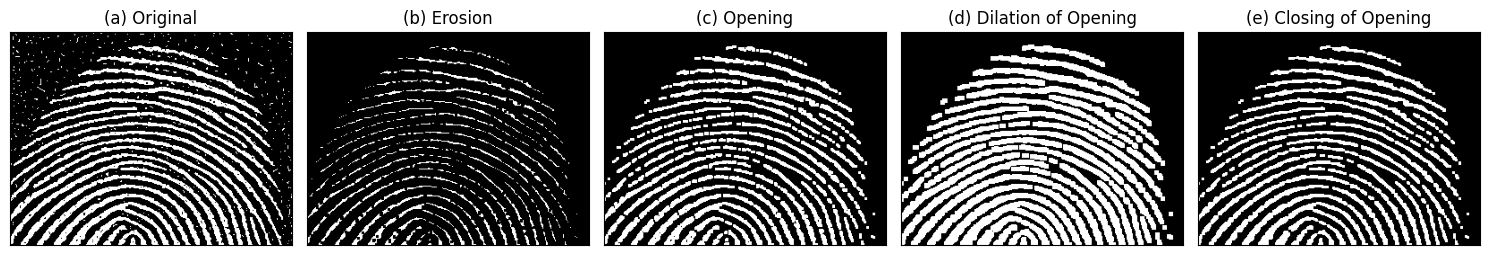

In [54]:
# 결과 출력
titles = ['(a) Original', '(b) Erosion', '(c) Opening', '(d) Dilation of Opening', '(e) Closing of Opening']
images = [img5, eroded, opened, dilated_open, closed]

plt.figure(figsize=(15,3))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

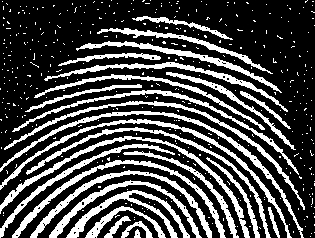

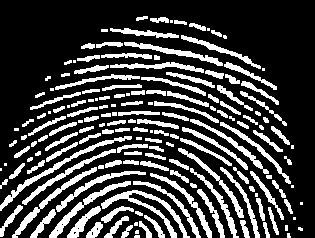

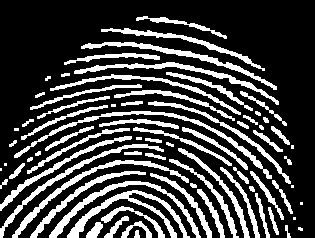

In [55]:
# 과제 5번 - 다른 방법
img5 = cv2.imread('/content/finger.jpg', cv2.IMREAD_GRAYSCALE)
morph = np.ones((3,3), np.uint8)
cv2_imshow(img5)

# Opening: 밝은 노이즈 제거
opening_img5 = cv2.morphologyEx(img5, cv2.MORPH_OPEN, morph, iterations=1)
cv2_imshow(opening_img5)

# Closing: 끊어진 지문 선 연결
closing_img = cv2.morphologyEx(opening_img5, cv2.MORPH_CLOSE, morph, iterations=1)
cv2_imshow(closing_img)

## HW#2-6
### 과제 내용

- 다음 영상에서 원하는 선분을 없애 보시고, 어떻게 했는지 분석하세요.   

### 분석 내용


- **Opening = Erosion + Dilation**

  - Erosion으로 SE보다 작은 선분을 제거한 뒤, Dilation으로 남은 객체를 원래 크기로 복원함.
  - 따라서 가는 wire bond 선분은 사라지고, 큰 패드 영역은 크기가 유지됨.

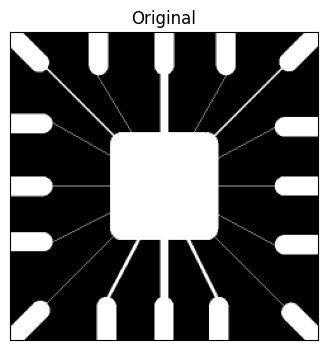

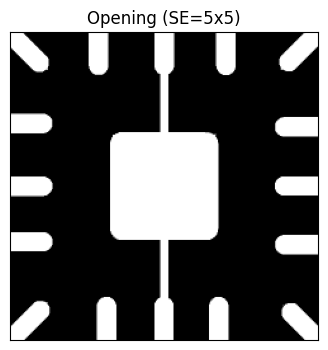

In [57]:
# 과제 6번
img6 = cv2.imread('/content/Fig0905(a)(wirebond-mask).tif', cv2.IMREAD_GRAYSCALE)

# 원본 이미지를 리사이즈
img6 = cv2.resize(img6, dsize=(0,0), fx=0.5, fy=0.5)

# 원본 출력
plt.figure(figsize=(4,4))
plt.imshow(img6, cmap='gray'), plt.xticks([]), plt.yticks([])
plt.title('Original')
plt.savefig('/content/01_original.png', dpi=100, bbox_inches='tight')
plt.show()

# Opening으로 가는 선분 제거
size = 5
morph = np.ones((size, size), np.uint8)
opening_img = cv2.morphologyEx(img6, cv2.MORPH_OPEN, morph, iterations=1)

plt.figure(figsize=(4,4))
plt.imshow(opening_img, cmap='gray'), plt.xticks([]), plt.yticks([])
plt.title(f'Opening (SE={size}x{size})')
plt.savefig('/content/02_opening.png', dpi=100, bbox_inches='tight')
plt.show()

## HW#2-7
### 과제 내용  
- 아래의 Edge 검출 알고리즘 사용하여 edge를 검출하고, 각각 결과가 어떻게 다른 지 비교하세요.
  - Sobel
  - Laplacian
  - Canny
  - Morphological Gradient

### 분석 내용  
- **Sobel**: x, y 방향의 1차 미분을 각각 구한 뒤 크기(magnitude)를 합산하여 edge를 검출한다. 방향성이 있어 수평/수직 edge에 민감하며, 비교적 부드러운 edge를 생성한다.

- **Laplacian**: 2차 미분을 사용하여 모든 방향의 edge를 한 번에 검출한다. Sobel보다 세밀한 edge를 잡아내지만, 노이즈에 민감하다는 단점이 있다.

- **Canny**: Gaussian 블러 → Sobel gradient → Non-Maximum Suppression → 이중 임계값의 단계를 거치는 다단계 알고리즘이다. 깨끗하고 얇은 1픽셀 두께의 edge를 생성하며, 4가지 중 가장 정제된 결과를 보여준다.

- **Morphological Gradient**: Dilation − Erosion으로 계산되며, 객체의 외곽 경계를 두껍게 검출한다. 다른 방법들보다 edge가 굵고, 노이즈에 비교적 강하다.

In [58]:
# 과제 7번
img7 = cv2.imread('/content/Fig0939(a)(headCT-Vandy).tif', cv2.IMREAD_GRAYSCALE)
img7 = cv2.resize(img7, dsize=(0,0), fx=0.5, fy=0.5)

In [59]:
# 1. Sobel
sobel_x = cv2.Sobel(img7, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img7, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobel_x, sobel_y)
sobel = np.uint8(np.clip(sobel, 0, 255))

# 2. Laplacian
laplacian = cv2.Laplacian(img7, cv2.CV_64F, ksize=3)
laplacian = np.uint8(np.clip(np.abs(laplacian), 0, 255))

# 3. Canny
canny = cv2.Canny(img7, 50, 150)

# 4. Morphological Gradient
morph_k = np.ones((3,3), np.uint8)
morph_grad = cv2.morphologyEx(img7, cv2.MORPH_GRADIENT, morph_k)

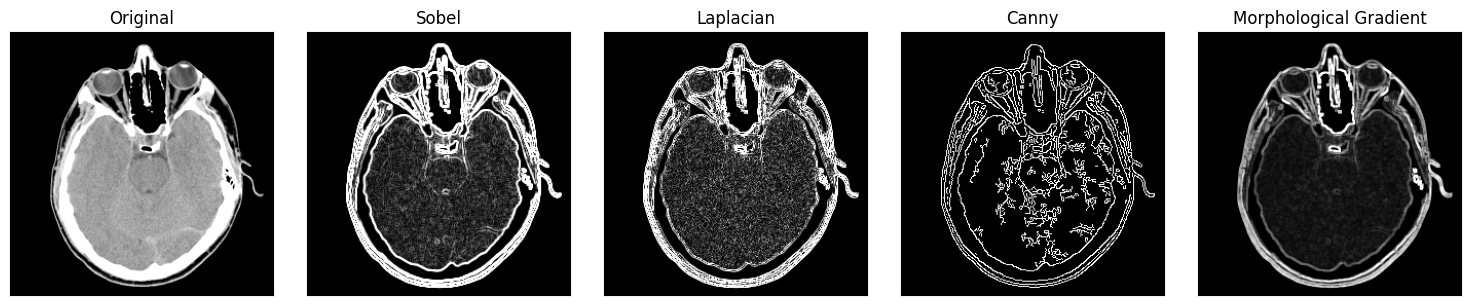

In [60]:
# 결과 출력
titles = ['Original', 'Sobel', 'Laplacian', 'Canny', 'Morphological Gradient']
images = [img7, sobel, laplacian, canny, morph_grad]

plt.figure(figsize=(15,3))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

## HW#2-8
### 과제 내용
- 아래의 알고리즘을 사용하여 노이즈라 생각되는 영역을 지우고, 각각 결과가 어떻게 다른 지 비교 분석하세요.
  - Morphological Smoothing
  - Smoothing Filter
### 분석 내용
1. **Morphological Smoothing**
- 강의 자료에 있는 3개지 방식을 모두 사용해보았습니다.
- **Opening → Closing**: Opening에서 밝은 노이즈(작은 밝은 점)를 먼저 제거한 뒤, Closing에서 어두운 노이즈(작은 어두운 점)를 제거한다. 전체적으로 "튀어나온 것 먼저 제거"하는 방식이다.
- **Closing → Opening**: Closing에서 어두운 노이즈를 먼저 메운 뒤, Opening에서 밝은 노이즈를 제거한다. Opening → Closing과 순서에 따라 결과가 미세하게 달라진다.
- **ASF (Alternating Sequential Filtering)**: Opening과 Closing을 번갈아가며 SE 크기를 3→5→7로 점진적으로 증가시키며 반복 적용한다. 작은 SE로 작은 노이즈를 먼저 제거하고, 큰 SE로 큰 구조를 정리하여 edge를 보존하면서 노이즈를 점진적으로 제거하는 edge-preserving filter이다.  

2. **Smoothing Filter (Gaussian)**: 주변 픽셀 값의 가중 평균으로 노이즈를 줄이지만, edge까지 함께 흐려지는 단점이 있다.

- 비교: Morphological 방식(Opening→Closing, Closing→Opening, ASF)은 edge를 보존하면서 노이즈를 제거하는 반면, Gaussian은 노이즈와 edge를 구분 없이 부드럽게 만든다.

In [61]:
# 과제 8번
img8 = cv2.imread('/content/Fig0938(a)(cygnusloop_Xray_original).tif', cv2.IMREAD_GRAYSCALE)
img8 = cv2.resize(img8, dsize=(0,0), fx=0.5, fy=0.5)

In [62]:
# 1. Morphological Smoothing
# 1-1. Opening → Closing
size = 5
morph_k = np.ones((size, size), np.uint8)
opened = cv2.morphologyEx(img8, cv2.MORPH_OPEN, morph_k)
morph_oc = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, morph_k)

# 1-2. Closing → Opening
closed = cv2.morphologyEx(img8, cv2.MORPH_CLOSE, morph_k)
morph_co = cv2.morphologyEx(closed, cv2.MORPH_OPEN, morph_k)

# 1-3. ASF (Alternating Sequential Filtering)
asf = img8.copy()
for s in [3, 5, 7]:
    k = np.ones((s, s), np.uint8)
    asf = cv2.morphologyEx(asf, cv2.MORPH_OPEN, k)
    asf = cv2.morphologyEx(asf, cv2.MORPH_CLOSE, k)

In [63]:
# 2. Smoothing Filter (Gaussian Blur)
gauss_smooth = cv2.GaussianBlur(img8, (5, 5), 0)

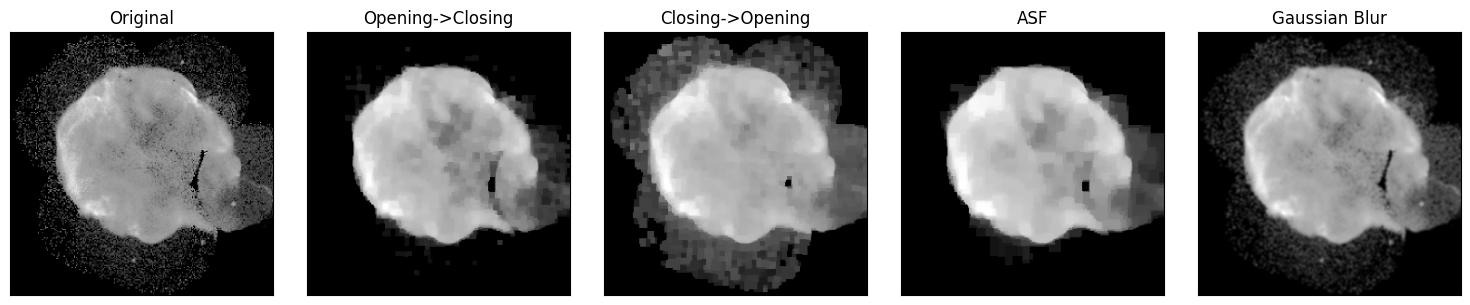

In [64]:
# 결과 출력
titles = ['Original', 'Opening->Closing', 'Closing->Opening', 'ASF', 'Gaussian Blur']
images = [img8, morph_oc, morph_co, asf, gauss_smooth]

plt.figure(figsize=(15,3))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

## HW#2-9
### 과제 내용
- 다음 영상을 이진화하되, 수업시간에 배운 2가지 방법을 모두 써보고, 각각의 결과에 대해 비교 분석하세요.
### 분석 내용
1. **원래 영상에 Otsu 이진화**: 전역적 임계값을 사용하는 Otsu 이진화를 바로 적용한다. 그러나 원본 영상의 배경 밝기가 균일하지 않기 때문에(왼쪽 위가 밝고 오른쪽 아래가 어두움), 어두운 영역의 쌀알이 배경으로 분류되거나 밝은 영역의 배경이 쌀알로 분류되는 오류가 발생한다.
2. **White Top-hat 변환 후 Otsu 이진화**: Top-hat 변환은 원영상에서 Opening 결과(배경에 해당)를 빼서 불균일한 배경 밝기를 제거한다. 반지름이 쌀알보다 충분히 큰 디스크 모양 SE(반지름 40)로 Opening하면 쌀알이 거의 제거되고 배경만 남으므로, 이를 빼면 배경이 균일해지고 밝은 극값과 어두운 극값의 차이가 줄어든다. 이 결과에 Otsu 이진화를 적용하면 모든 쌀알이 성공적으로 추출된다.
- 비교: 비균일 조명 아래에서는 단순 Otsu 이진화가 실패하지만, Top-hat 변환으로 배경을 먼저 제거하면 성공적인 이진화가 가능하다. Top-hat 변환은 배경영상의 추출을 위해 사용되는 핵심 전처리 단계이다.

In [65]:
# 과제 9번
img9 = cv2.imread('/content/Fig0940(a)(rice_image_with_intensity_gradient).tif', cv2.IMREAD_GRAYSCALE)
img9 = cv2.resize(img9, dsize=(0,0), fx=0.5, fy=0.5)

In [66]:
# 방법 1: 원래 영상에 대한 Otsu 이진화
otsu_th, otsu_direct = cv2.threshold(img9, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 방법 2: White Top-hat 변환 후 Otsu 이진화
# 반지름 40인 디스크 모양 SE → Opening으로 배경 추출
se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (81, 81))
tophat = cv2.morphologyEx(img9, cv2.MORPH_TOPHAT, se)
otsu_th, otsu_tophat = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

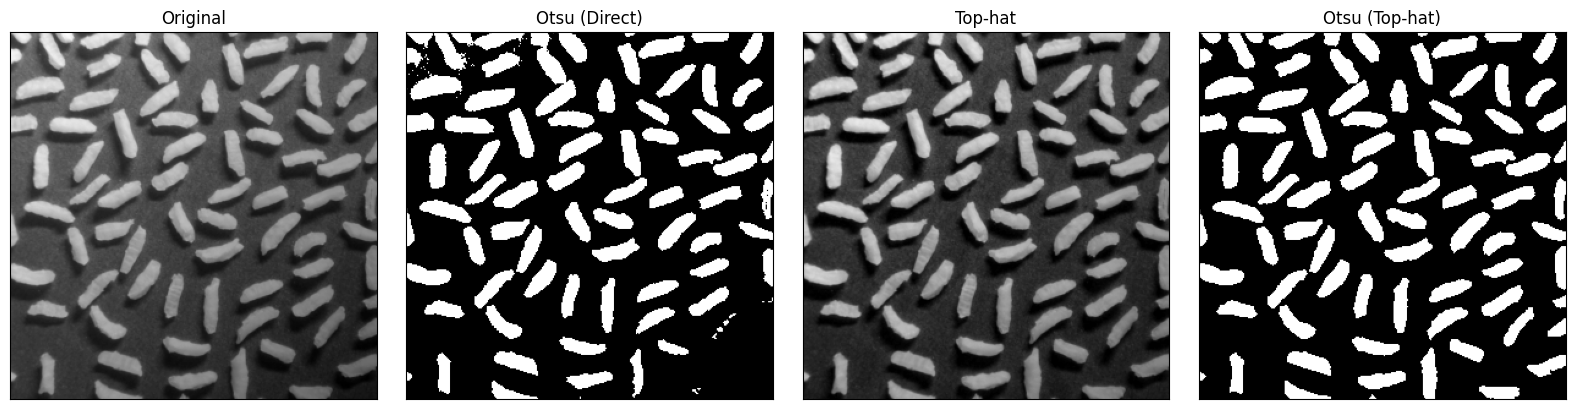

In [67]:
# 결과 출력
titles = ['Original', 'Otsu (Direct)', 'Top-hat', 'Otsu (Top-hat)']
images = [img9, otsu_direct, tophat, otsu_tophat]

plt.figure(figsize=(16,4))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

## HW#2-10
### 과제 내용
- 다음 영상을 Morphology를 적용하여 분할하세요.

### 분석 내용
- **Closing** (SE=30): 관심 객체(큰 원)가 배경보다 어두우므로, 작은 얼룩들보다 더 큰 SE로 Closing 연산을 수행하여 작은 얼룩(small blobs)을 제거한다. 작은 얼룩 크기가 약 25이므로 SE 크기를 30으로 설정한다.
- **Opening** (SE=60): 얼룩들 간의 간격에 비해 큰 SE(크기 60)를 적용하여 Opening 연산을 수행하면, 큰 얼룩들 사이의 밝은 패치가 제거되고 두 종류의 영역(큰 원 영역 / 배경 영역)으로 분리된다.
- **Morphological Gradient**: Dilation − Erosion의 차이를 이용하여 분리된 영역의 경계선을 추출한다.
Result: 추출한 경계선을 원본 영상에 합성하여 최종 분할 결과를 생성한다. 두 종류의 얼룩(큰 원, 작은 원) 영역이 경계선으로 구분된다.

In [68]:
# 과제 10번
img10 = cv2.imread('/content/Fig0943(a)(dark_blobs_on_light_background).tif', cv2.IMREAD_GRAYSCALE)
img10 = cv2.resize(img10, dsize=(0,0), fx=0.5, fy=0.5)

# (b) 작은 얼룩 제거 - Closing 수행(작은 얼룩 크기:25, SE 크기:30)
se_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (30, 30))
closing_img = cv2.morphologyEx(img10, cv2.MORPH_CLOSE, se_close)

# (c) 얼룩들 간의 밝은 패치 제거 - Opening 연산 (SE 크기:60)
se_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (60, 60))
opening_img = cv2.morphologyEx(closing_img, cv2.MORPH_OPEN, se_open)

# (d) Morphological Gradient로 경계 추출
se_grad = np.ones((3, 3), np.uint8)
gradient = cv2.morphologyEx(opening_img, cv2.MORPH_GRADIENT, se_grad)

# 경계를 원본에 합성 (경계 부분을 흰색으로)
result = img10.copy()
result[gradient > 10] = 255

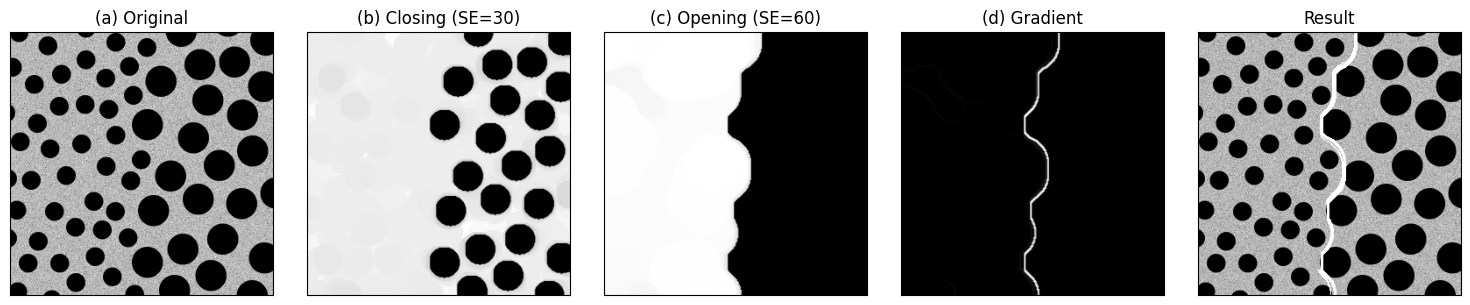

In [69]:
# 결과 출력
titles = ['(a) Original', '(b) Closing (SE=30)', '(c) Opening (SE=60)', '(d) Gradient', 'Result']
images = [img10, closing_img, opening_img, gradient, result]
plt.figure(figsize=(15,3))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()